#RNN

#1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense


#2. Load Data set

In [ ]:
df = pd.read_csv("/content/monthly_milk_production.csv")

print(df.head())
print(df.columns)


      Date  Production
0  1962-01         589
1  1962-02         561
2  1962-03         640
3  1962-04         656
4  1962-05         727
Index(['Date', 'Production'], dtype='object')


#3. Clean Data

In [ ]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

date_col = df.columns[0]
df[date_col] = pd.to_datetime(df[date_col])

df.set_index(date_col, inplace=True)

print(df.head())


            production
date                  
1962-01-01         589
1962-02-01         561
1962-03-01         640
1962-04-01         656
1962-05-01         727


#4. Select Target Series

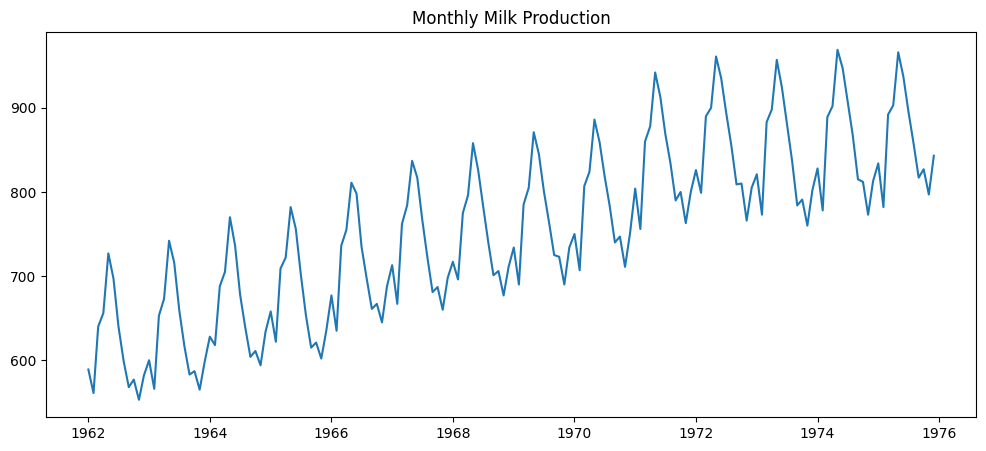

In [ ]:
series = df.iloc[:, 0]

plt.figure(figsize=(12,5))
plt.plot(series)
plt.title("Monthly Milk Production")
plt.show()


#5. Scaling

In [ ]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(series.values.reshape(-1,1))


#6. Create Sequences

In [ ]:
def create_sequences(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return np.array(X), np.array(y)

window_size = 12
X, y = create_sequences(scaled_data, window_size)


#7. Train-Test Split

In [ ]:
train_size = int(len(X) * 0.7)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]


#8. RNN Buliding

In [ ]:
rnn = Sequential([
    SimpleRNN(50, activation='relu', input_shape=(window_size,1)),
    Dense(1)
])

rnn.compile(optimizer='adam', loss='mse')
rnn.fit(X_train, y_train, epochs=50, batch_size=16, verbose=1)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1837
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0770 
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0263 
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0220 
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0181 
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0166 
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0157 
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0142 
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0138 
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0129 
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0124 
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0116 
Epoch 13/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0112 
Epoch 14/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0100 
Epoch 15/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0087 
Epoch 16/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/st

#9. LSTM Model

In [ ]:
lstm = Sequential([
    LSTM(50, activation='relu', input_shape=(window_size,1)),
    Dense(1)
])

lstm.compile(optimizer='adam', loss='mse')
lstm.fit(X_train, y_train, epochs=50, batch_size=16, verbose=1)


Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1491
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0864 
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0428 
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0242 
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0265 
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0223 
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0232 
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0222 
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0219
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0215 
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0211
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0209 
Epoch 13/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0206 
Epoch 14/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0201 
Epoch 15/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0201 
Epoch 16/50
7/7 ━━━━━━━━━━━━━━━━━━━

#10. GRU Model

In [ ]:
gru = Sequential([
    GRU(50, activation='relu', input_shape=(window_size,1)),
    Dense(1)
])

gru.compile(optimizer='adam', loss='mse')
gru.fit(X_train, y_train, epochs=50, batch_size=16, verbose=1)


Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.1050
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0520 
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0264 
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0206
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0204 
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0177 
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0172
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0165
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0160
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0157
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0152
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0150 
Epoch 13/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0147
Epoch 14/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0142
Epoch 15/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0140
Epoch 16/50
7/7 ━━━━━━━━━━━━━━━━━━━

#11. Predictions

In [ ]:
rnn_pred = rnn.predict(X_test)
lstm_pred = lstm.predict(X_test)
gru_pred = gru.predict(X_test)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 377ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step


1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step


#12. Inverse Transform

In [ ]:
y_test_actual = scaler.inverse_transform(y_test)
rnn_pred = scaler.inverse_transform(rnn_pred)
lstm_pred = scaler.inverse_transform(lstm_pred)
gru_pred = scaler.inverse_transform(gru_pred)


#13. Metrics

In [ ]:
def evaluate(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred)/y_true))*100
    return rmse, mae, mape

print("RNN:", evaluate(y_test_actual, rnn_pred))
print("LSTM:", evaluate(y_test_actual, lstm_pred))
print("GRU:", evaluate(y_test_actual, gru_pred))


RNN: (np.float64(17.78974067614309), 14.009408504404908, np.float64(1.6661865226322896))
LSTM: (np.float64(44.88628828044701), 37.01726645611702, np.float64(4.341138708007695))
GRU: (np.float64(39.061479470774664), 29.562144178025257, np.float64(3.5162027842305417))


#14. Visualization

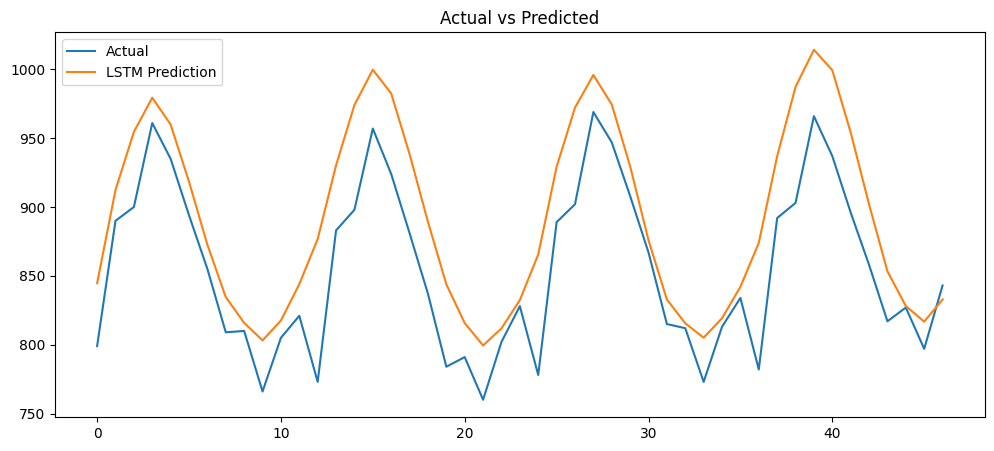

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(y_test_actual, label='Actual')
plt.plot(lstm_pred, label='LSTM Prediction')
plt.legend()
plt.title("Actual vs Predicted")
plt.show()


#15. Forecasting

In [ ]:
future_steps = 12
input_seq = X_test[-1]

future = []

for _ in range(future_steps):
    pred = lstm.predict(input_seq.reshape(1,window_size,1))
    future.append(pred[0][0])
    input_seq = np.append(input_seq[1:], pred, axis=0)

future = scaler.inverse_transform(np.array(future).reshape(-1,1))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


#16. Plot Forecast

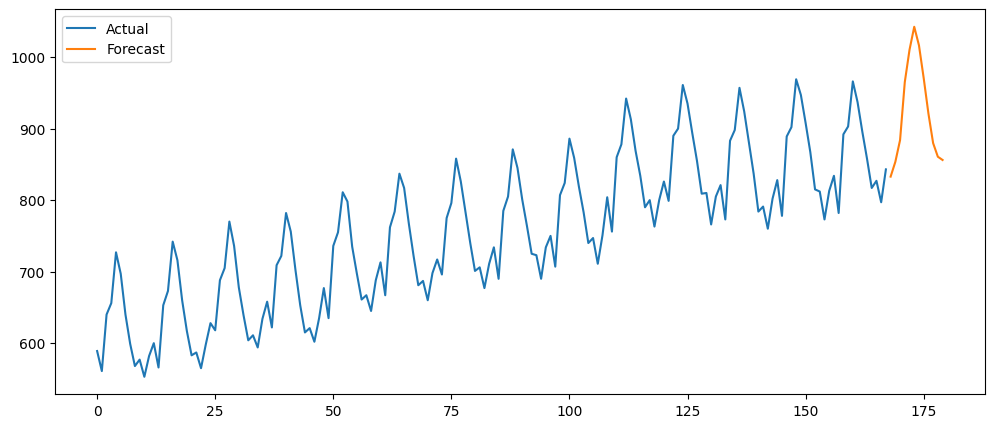

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(series.values, label='Actual')
plt.plot(range(len(series), len(series)+12), future, label='Forecast')
plt.legend()
plt.show()


#Finally
#####Loaded time series dataset
#####Converted date column
#####Scaled data
#####Created sequences for RNN input
#####Built RNN, LSTM, GRU models
#####Compared performance
#####Forecasted future values

#Conclusion

#####In this project, a time series forecasting analysis was performed using the Monthly Milk Production dataset. The data was preprocessed by converting the date column, setting it as the index, and scaling the production values to improve neural network performance. Sequences were created using a sliding window approach to convert the time series into a supervised learning format suitable for deep learning models.

#####Three recurrent neural network architectures — Simple RNN, LSTM, and GRU — were implemented and trained on the dataset to predict future milk production values. Their performances were evaluated using error metrics such as RMSE, MAE, and MAPE.

#####From the results, it was observed that:

###LSTM performed better in capturing long-term dependencies in the data.
###GRU provided similar performance to LSTM but with slightly faster training.
###Simple RNN showed comparatively lower accuracy due to its limitation in handling long-term patterns.

#####The forecasting results showed that the models were able to capture the overall trend and seasonality in milk production effectively. Finally, future values were predicted for the next 12 months, demonstrating the practical use of deep learning in time series forecasting.